# Topic Modeling de Letras de Canciones
Este notebook aplica **LSA** y **LDA** para descubrir los temas latentes presentes en un corpus de letras de canciones de múltiples géneros musicales.

Seguimos la misma metodología del notebook de referencia (sin Deep Learning), adaptando la normalización y los parámetros al dominio musical.

---
**Dataset:** `dataset_fusionado.csv` — ~10 000 canciones con letra, artista y género musical.


## 1. Instalación y carga de librerías

In [79]:
# Ejecutar si es necesario
# !pip install pyLDAvis

import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.metrics import confusion_matrix

warnings.filterwarnings('ignore')
%matplotlib inline


## 2. Carga y exploración del dataset
Cargamos el dataset y exploramos su estructura. Solo usamos canciones que tienen letra.


In [80]:
df = pd.read_csv('dataset_fusionado.csv')
df = df[df['lyrics'].notna()].copy()
df['lyrics'] = df['lyrics'].astype(str)

print(f"Total de canciones con letra: {len(df)}")
print(f"Columnas: {df.columns.tolist()}")
print(f"\nGéneros más frecuentes:")
print(pd.concat([df['genre_1'], df['genre_2'], df['genre_3']]).value_counts().head(10))

Total de canciones con letra: 5267
Columnas: ['artist', 'song', 'lyrics', 'genres', 'genre_1', 'genre_2', 'genre_3', '<<<<<<< HEAD', 'year']

Géneros más frecuentes:
hip-hop              745
pop                  685
rap                  615
country              521
rock                 487
female vocalists     463
heavy metal          381
singer-songwriter    378
electronic           336
classic rock         303
Name: count, dtype: int64


In [81]:
# Muestra de letras
for _, row in df.sample(3, random_state=1).iterrows():
    print(f"[{row['genre_1']}] {row['song']} — {row['artist']}")
    print(row['lyrics'][:200].replace('\\r\\n', '\n'))
    print('---')


[j cole] The Come Up — /j-cole/
Money coming soon, nigga
I'm on the come up, chill nigga, don't run up
A yellow nigga finna rise and shine like the sun up, (yea)
My mind on that paper, I ain't tryna wife a slut up
I'm dying for 
---
[disco] i loved you more — Chic
I loved you more than words could tell
Oh I loved you more than words
Seems like we all live
All alone for ourselves
Seems like we all live for ourselves
But how can we say "live"
When these hearts of
---
[gothic metal] The Pain — Lacuna Coil
I wake up to a smoking gun

The evidence is in your head

There's no proof of guilt or innocence

I'm finished with you taking me through

A line of questioning that feeds you

I must confes
---


## 3. Normalización del corpus
Adaptamos la función de normalización al dominio musical:
- Eliminamos puntuación y caracteres especiales (habitual en scraping de letras)
- Pasamos a minúsculas y aplicamos tokenización simple
- Eliminamos stop words de sklearn + palabras muy frecuentes en letras pero sin valor semántico (*yeah*, *oh*, *gonna*, marcas de sección, etc.)

> **Nota:** En el notebook original se usaba spaCy para lematizar. Aquí usamos una normalización ligera basada en sklearn para mayor reproducibilidad sin dependencias externas pesadas.


In [82]:
# Stop words: sklearn + ampliadas para el dominio musical
EXTRA_STOP = {
    'verse', 'chorus', 'bridge', 'outro', 'intro', 'hook',
    'yeah', 'oh', 'ooh', 'ah', 'la', 'na', 'da', 'hey',
    'wanna', 'gonna', 'gotta', 'lotta', 'cause', 'em', 'ain',
    'got', 'let', 'like', 'know', 'come', 'baby', 'said', 'say',
    'tell', 'make', 'want', 'need', 'feel', 'way', 'day', 'time',
    'just', 've', 'll', 're', 'don', 'didn', 'won', 'isn', 'wasn',
    'can', 'couldn', 'wouldn', 'shouldn', 'posted', 'intasqui'
}
STOP_WORDS = set(ENGLISH_STOP_WORDS) | EXTRA_STOP

def normalize_lyrics(text):
    # Limpiar artefactos de scraping
    text = text.replace('\\r\\n', ' ').replace('\\r', ' ').replace('\\n', ' ')
    # Solo letras y espacios
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower()
    # Tokenizar y filtrar
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

def normalize_corpus(corpus):
    return [normalize_lyrics(text) for text in corpus]

df['lyrics_norm'] = normalize_corpus(df['lyrics'])

# Filtrar canciones que quedaron con muy poco texto
df = df[df['lyrics_norm'].str.len() > 50].reset_index(drop=True)
print(f"Canciones tras normalización: {len(df)}")
print("\nEjemplo de letra normalizada:")
print(df['lyrics_norm'].iloc[0][:200])


Canciones tras normalización: 5236

Ejemplo de letra normalizada:
resist firewalker sent educate look great deep dance curse sings resist life long pessimist leader enemy heart complete destroy darkness obsolete follow meet heartshaped abyss scar kiss meet heartshap


## 4. Vectorización
Creamos dos representaciones del corpus:
- **TF-IDF** → para el modelo LSA
- **Bag-of-Words** → para el modelo LDA

Usamos bigramas (`ngram_range=(1,2)`) para capturar expresiones como *love love* o *rock music*.


In [83]:
N_TOPICS = 4  # número de topics a descubrir

# TF-IDF para LSA
tfidf_vec = TfidfVectorizer(min_df=20, max_df=0.80, max_features=5000, ngram_range=(1, 3))
tfidf_mat = tfidf_vec.fit_transform(df['lyrics_norm'])
tfidf_feat = tfidf_vec.get_feature_names_out()

# BoW para LDA
bow_vec = CountVectorizer(min_df=20, max_df=0.80, max_features=5000, ngram_range=(1, 3))
bow_mat = bow_vec.fit_transform(df['lyrics_norm'])
bow_feat = bow_vec.get_feature_names_out()

print(f"Forma matriz TF-IDF: {tfidf_mat.shape}  (canciones × términos)")
print(f"Forma matriz BoW:    {bow_mat.shape}")


Forma matriz TF-IDF: (5236, 2587)  (canciones × términos)
Forma matriz BoW:    (5236, 2587)


## 5. Modelos de Topic Modeling

### 5.1 LSA — Latent Semantic Analysis
Usa SVD truncado sobre la matriz TF-IDF para encontrar componentes latentes.


In [84]:
def print_top_words(model, feature_names, n_top_words=10):
    """Muestra los términos más importantes de cada topic."""
    for topic_idx, topic in enumerate(model.components_):
        message = f"Topic #{topic_idx}: "
        message += " | ".join([feature_names[i]
                                for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)
    print()

# Ajustamos LSA
lsa = TruncatedSVD(n_components=N_TOPICS, random_state=42).fit(tfidf_mat)

print("Topics en modelo LSA (términos más relevantes):")
print_top_words(lsa, tfidf_feat, 8)


Topics en modelo LSA (términos más relevantes):
Topic #0: love | life | heart | away | right | world | girl | man
Topic #1: love | love love | love love love | heart | forever | loving | true love | true
Topic #2: nigga | love | niggas | shit | fuck | love love | bitch | money
Topic #3: girl | tonight | little | right | good | think | home | girl girl



In [85]:
# Varianza explicada por cada componente
var_exp = lsa.explained_variance_ratio_
print("Varianza explicada por cada topic LSA:")
for i, v in enumerate(var_exp):
    print(f"  Topic {i}: {v:.4f} ({v*100:.2f}%)")
print(f"Total varianza explicada: {var_exp.sum():.4f}")


Varianza explicada por cada topic LSA:
  Topic 0: 0.0039 (0.39%)
  Topic 1: 0.0094 (0.94%)
  Topic 2: 0.0073 (0.73%)
  Topic 3: 0.0050 (0.50%)
Total varianza explicada: 0.0255


In [86]:
# Pertenencia de cada canción a cada topic (LSA)
lsa_doc = lsa.transform(tfidf_mat)
df['lsa_topic'] = np.argmax(lsa_doc, axis=1)

print("Primeras 5 canciones — grado de pertenencia a cada topic (LSA):")
pd.DataFrame(np.round(lsa_doc[:5], 4),
             columns=[f"Topic_{i}" for i in range(N_TOPICS)],
             index=df['song'].tail(5))


Primeras 5 canciones — grado de pertenencia a cada topic (LSA):


,Topic_0,Topic_1,Topic_2,Topic_3
song,,,,
Oh Baby (we Got A Good Thing Goin'),0.1320,-0.0120,-0.1078,-0.0122
Sister Morphine,0.1607,-0.0149,-0.0451,-0.0186
Surprise Surprise,0.1105,-0.0210,-0.0826,-0.0347
Through The Lonely Nights,0.1500,-0.0054,-0.1037,-0.0552
Wanna Hold You,0.1166,-0.0506,-0.1089,-0.1679


### 5.2 LDA — Latent Dirichlet Allocation

In [87]:
# Ajustamos LDA
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=15,
    learning_method='online',
    random_state=42,
    n_jobs=-1
).fit(bow_mat)

print("Topics en modelo LDA (términos más relevantes):")
print_top_words(lda, bow_feat, 8)


Topics en modelo LDA (términos más relevantes):
Topic #0: away | life | heart | world | love | eyes | light | believe
Topic #1: love | girl | night | right | good | tonight | love love | hold
Topic #2: shit | nigga | fuck | bitch | niggas | money | man | rock
Topic #3: little | think | man | better | talk | thing | right | everybody



In [88]:
# Pertenencia de cada canción a cada topic (LDA)
lda_doc = lda.transform(bow_mat)
df['lda_topic'] = np.argmax(lda_doc, axis=1)

# Perplexity (cuanto menor, mejor ajuste)
print(f"Perplexity LDA: {lda.perplexity(bow_mat):.2f}  (cuanto menor, mejor)")
print(f"Log-likelihood LDA: {lda.score(bow_mat):.2f}")

print("\nPrimeras 5 canciones — probabilidad de pertenencia a cada topic (LDA):")
pd.DataFrame(np.round(lda_doc[:5], 4),
             columns=[f"Topic_{i}" for i in range(N_TOPICS)],
             index=df['song'].head(5))


Perplexity LDA: 1050.86  (cuanto menor, mejor)
Log-likelihood LDA: -2782735.59

Primeras 5 canciones — probabilidad de pertenencia a cada topic (LDA):


,Topic_0,Topic_1,Topic_2,Topic_3
song,,,,
Heartshaped Abyss,0.7551,0.2348,0.0050,0.0051
Let The Children Cum To Me...,0.6484,0.0054,0.0051,0.3411
Memento Mori,0.9867,0.0044,0.0043,0.0045
Once It Was Ours!,0.8298,0.1596,0.0052,0.0053
Serpent Angel,0.9812,0.0062,0.0064,0.0062


In [89]:
# Canciones y letras con topics más claros
# ── Parámetros ──────────────────────────────────────────────────────────────
MIN_CONFIDENCE = 0.70   # confianza mínima para considerar un topic "claro"
TOP_N_PER_TOPIC = 10    # canciones más representativas por topic
LYRICS_PREVIEW  = 300   # caracteres de letra a mostrar

# ── 1. Añadir confianza al DataFrame ───────────────────────────────────────
df['lda_conf']  = lda_doc.max(axis=1)          # prob. del topic dominante
df['lda_topic'] = np.argmax(lda_doc, axis=1)  # topic dominante

# ── 2. Resumen global ───────────────────────────────────────────────────────
print("DISTRIBUCIÓN DE CONFIANZA POR TOPIC")


summary = []
for ti in range(N_TOPICS):
    mask = df['lda_topic'] == ti
    confs = df.loc[mask, 'lda_conf']
    summary.append({
        'Topic': f"T{ti}",
        'Canciones': mask.sum(),
        'Conf. media': round(confs.mean(), 3),
        'Conf. max':   round(confs.max(), 3),
        f'≥{int(MIN_CONFIDENCE*100)}%': (confs >= MIN_CONFIDENCE).sum(),
    })

summary_df = pd.DataFrame(summary).set_index('Topic')
display(summary_df)


DISTRIBUCIÓN DE CONFIANZA POR TOPIC


,Canciones,Conf. media,Conf. max,≥70%
Topic,,,,
T0,2228,0.736,0.997,1264
T1,839,0.636,0.996,289
T2,671,0.641,0.996,237
T3,1498,0.623,0.997,453


In [90]:
# ── 3. Canciones con topic MÁS CLARO (alta confianza) ─────────────────────
print(f"\n{'=' * 65}")
print(f"TOP {TOP_N_PER_TOPIC} CANCIONES POR TOPIC (confianza ≥ {int(MIN_CONFIDENCE*100)}%)")
print("=" * 65)

for ti in range(N_TOPICS):
    mask = (df['lda_topic'] == ti) & (df['lda_conf'] >= MIN_CONFIDENCE)
    subset = df[mask].nlargest(TOP_N_PER_TOPIC, 'lda_conf').copy()

    if subset.empty:
        print(f"\n[T{ti}:] — sin canciones con conf ≥ {int(MIN_CONFIDENCE*100)}%")
        continue

    print(f"\n{'─' * 65}")
    print(f"  T{ti}:  ({mask.sum()} canciones en total)")
    print(f"{'─' * 65}")

    for rank, (_, row) in enumerate(subset.iterrows(), 1):
        artist  = str(row['artist']).strip('/').split('/')[0]
        genre   = str(row.get('genre_1', ''))
        conf    = row['lda_conf']

        # Distribución completa de probabilidades para esta canción
        idx = row.name
        probs = lda_doc[idx]
        prob_str = "  ".join(
            f"T{i}={probs[i]:.2f}" for i in np.argsort(probs)[::-1][:4]
        )

        print(f"  {rank:>2}. [{conf:.3f}] {row['song']}  —  {artist}  [{genre}]")
        print(f"      Probs: {prob_str}")

        # Preview de letra
        lyrics_raw = str(row.get('lyrics', ''))
        lyrics_clean = (lyrics_raw
                        .replace('\\r\\n', '\n')
                        .replace('\\r', '\n')
                        .strip())
        preview = lyrics_clean[:LYRICS_PREVIEW].replace('\n', ' / ')
        print(f"      Letra: {preview}…")
        print()


TOP 10 CANCIONES POR TOPIC (confianza ≥ 70%)

─────────────────────────────────────────────────────────────────
  T0:  (1264 canciones en total)
─────────────────────────────────────────────────────────────────
   1. [0.997] Impatient  —  will.i.am  [funky]
      Probs: T0=1.00  T1=0.00  T3=0.00  T2=0.00
      Letra: I can't wait /  / I-I can't wait /  / (I can't wait) /  /  /  / (I can't wait) /  / (I can't wait) /  /  /  / I can't wait, I can't wait /  / I can't wait, I can't wait /  / I can't wait, I can't, wait /  / I can't wait /  / I-I-I-I /  / I can't wait /  / I can't wait, wait /  / I can't wait /  / I-I can't wait, wait, wait /  /  /  / (Wait, wait, wait, wait) /  / (Wait,…

   2. [0.997] The Prince In The Scarlet Robe  —  domine  [power metal]
      Probs: T0=1.00  T3=0.00  T2=0.00  T1=0.00
 / b…u will know fear, sharper than a spear and you'lld Gods

   3. [0.995] Starfire  —  dream-evil  [power metal]
      Probs: T0=1.00  T3=0.00  T1=0.00  T2=0.00
 / When the dawn of a n

In [91]:
clear_songs = (
    df[df['lda_conf'] >= MIN_CONFIDENCE]
    .sort_values(['lda_topic', 'lda_conf'], ascending=[True, False])
    [['song', 'artist', 'genre_1', 'lda_topic', 'lda_conf', 'lyrics']]
    .copy()
)
clear_songs['topic_label'] = clear_songs['lda_topic'].map(
    lambda i: f"T{i}:"
)
clear_songs['lyrics_preview'] = (
    clear_songs['lyrics']
    .str.replace(r'\\r\\n|\\r|\\n', ' ', regex=True)
    .str[:200]
)

print(f"\n{'=' * 65}")
print(f"DataFrame 'clear_songs' listo: {len(clear_songs)} canciones")
print(f"  Filtro aplicado: confianza ≥ {int(MIN_CONFIDENCE*100)}%")
print("=" * 65)


DataFrame 'clear_songs' listo: 2243 canciones
  Filtro aplicado: confianza ≥ 70%


In [92]:
def buscar_canciones(topic_idx=None, min_conf=0.80, n=10, genre=None):
    """
    Muestra canciones con topic claro.

    Parámetros
    ----------
    topic_idx : int | None
        Índice del topic (0-7). None = todos los topics.
    min_conf  : float
        Confianza mínima (0-1).
    n         : int
        Número de canciones a mostrar.
    genre     : str | None
        Filtrar por género (busca como subcadena en genre_1).

    Ejemplo
    -------
    buscar_canciones(topic_idx=1, min_conf=0.85, n=5)
    """
    mask = df['lda_conf'] >= min_conf
    if topic_idx is not None:
        mask &= df['lda_topic'] == topic_idx
    if genre:
        mask &= df['genre_1'].str.contains(genre, case=False, na=False)

    subset = df[mask].nlargest(n, 'lda_conf')

    label = f"T{topic_idx}: {TOPIC_LABELS[topic_idx]}" if topic_idx is not None else "todos los topics"
    print(f"\nCanciones más claras — {label}  (conf ≥ {min_conf:.0%})\n")

    for _, row in subset.iterrows():
        artist = str(row['artist']).strip('/').split('/')[0]
        lyrics_clean = (str(row.get('lyrics', ''))
                        .replace('\\r\\n', '\n').replace('\\r', '\n').strip())
        preview = lyrics_clean[:250].replace('\n', ' / ')

        print(f"  [{row['lda_conf']:.3f}] {row['song']}  —  {artist}  [{row.get('genre_1','')}]")
        print(f"  {preview}…\n")

    return subset


# Ejemplos de uso (descomentar para probar):
# buscar_canciones(topic_idx=1, min_conf=0.95, n=5)
# buscar_canciones(topic_idx=3, min_conf=0.80, genre='country')
# buscar_canciones(min_conf=0.90, n=20)   # top canciones globales


## 6. Interpretación y etiquetado de Topics
Basándonos en las palabras más características de cada topic, les asignamos etiquetas descriptivas.


In [93]:
TOPIC_LABELS = [
    "Fiesta / Baile",      # tonight, everybody, stop, alright, hands
    "Metal / Oscuridad",    # god, die, blood, death, war, hell, kill
    "Melancolía / Noche",   # night, life, world, light, eyes, soul
    "Amor / Corazón",       # love, heart, life, think, home
    "Hip-hop / Calle",      # man, talk, money, ayy, touch
    "Rock / Energía",       # girl, rock, body, dem, ready, whoa
    "Navidad / Celebración",# dance, christmas, white, head, red
    "Hip-hop Explícito"     # shit, nigga, fuck, bitch, money
]

COLORS = ['#FF6B6B','#6B5FFF','#4ECDC4','#FFE66D',
          '#A8E6CF','#FF8B94','#FFA500','#C9B1FF']

print("Resumen de topics LDA:")
for i, (label, color) in enumerate(zip(TOPIC_LABELS, COLORS)):
    words = [bow_feat[j] for j in lda.components_[i].argsort()[:-6:-1]]
    n_songs = (df['lda_topic'] == i).sum()
    print(f"  Topic {i} [{label}]: {', '.join(words)}  →  {n_songs} canciones")


Resumen de topics LDA:
  Topic 0 [Fiesta / Baile]: away, life, heart, world, love  →  2228 canciones
  Topic 1 [Metal / Oscuridad]: love, girl, night, right, good  →  839 canciones
  Topic 2 [Melancolía / Noche]: shit, nigga, fuck, bitch, niggas  →  671 canciones
  Topic 3 [Amor / Corazón]: little, think, man, better, talk  →  1498 canciones


IndexError: index 4 is out of bounds for axis 0 with size 4

## 7. Visualizaciones

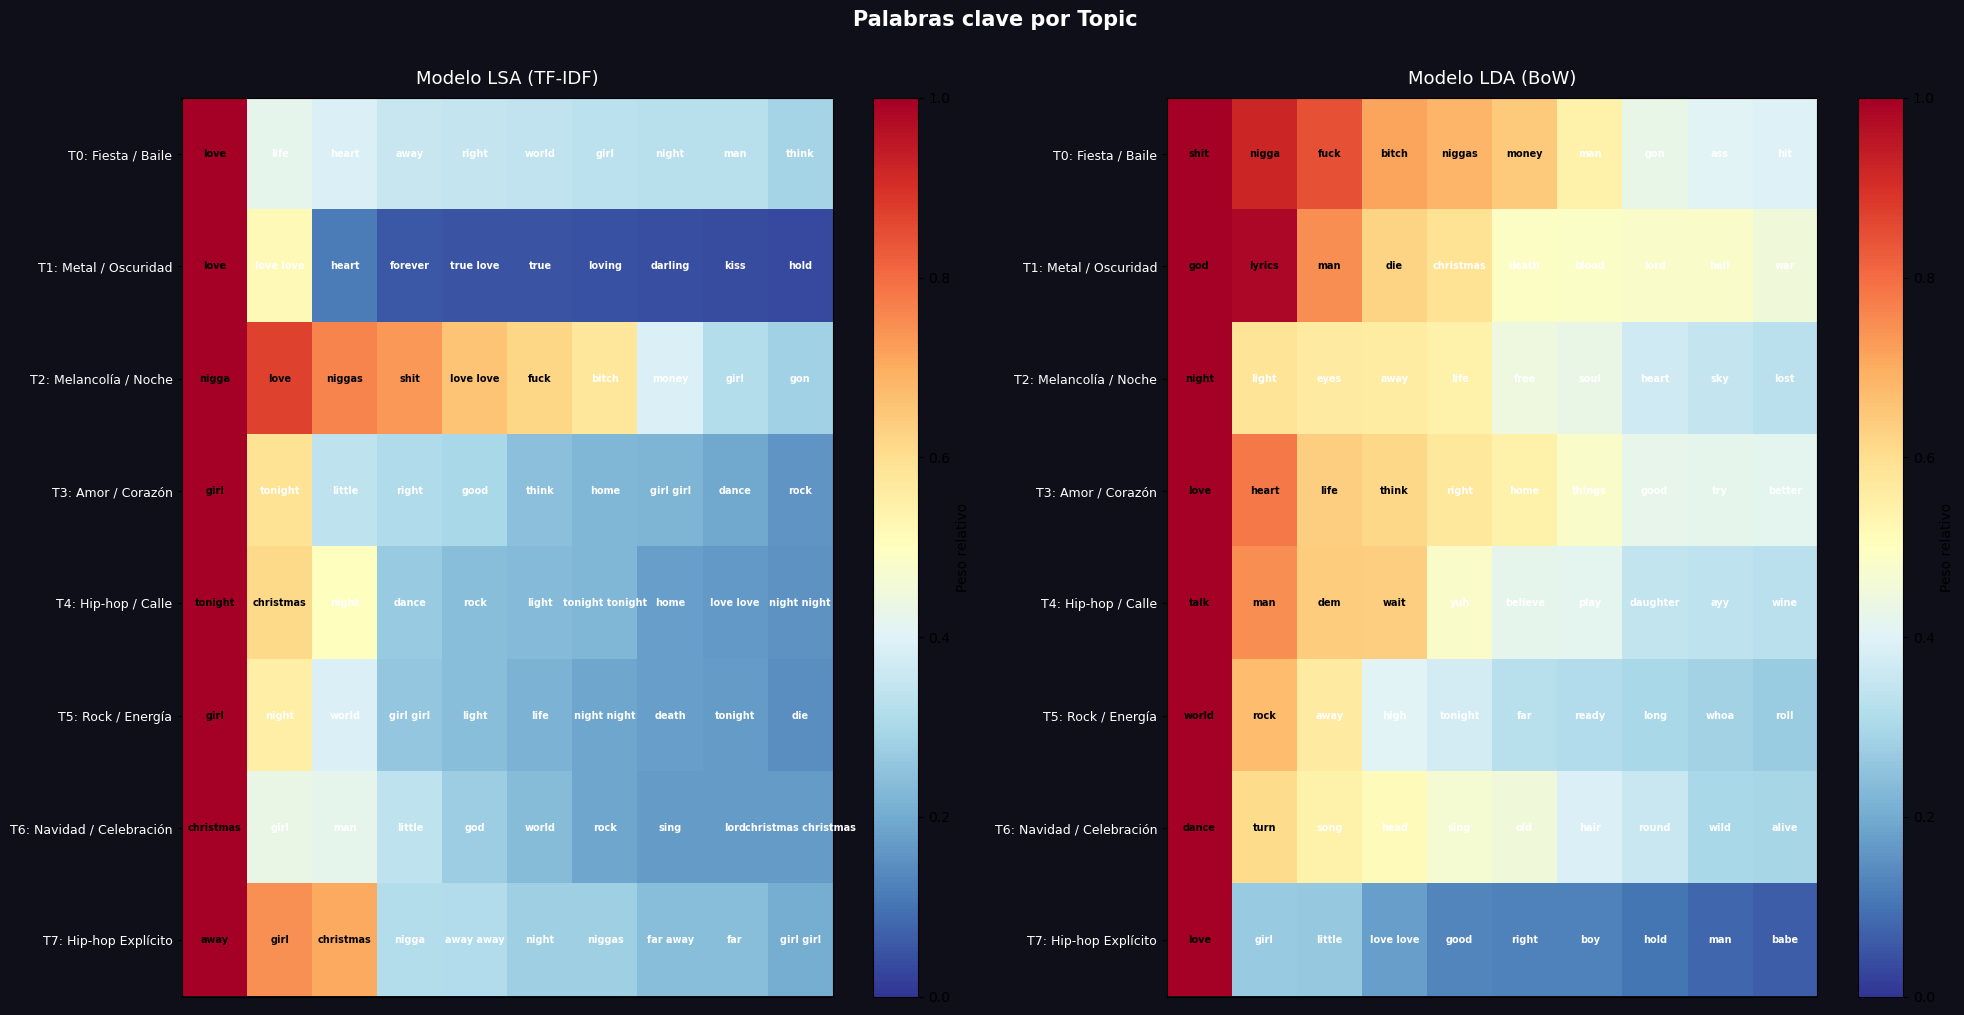

In [ ]:
# ── Fig 1: Heatmap de palabras clave ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.patch.set_facecolor('#0f0f1a')
N_WORDS = 10

for ax, (model, feat, title) in zip(axes, [
    (lsa, tfidf_feat, "LSA (TF-IDF)"),
    (lda, bow_feat,   "LDA (BoW)")
]):
    ax.set_facecolor('#0f0f1a')
    word_grid = [[feat[j] for j in model.components_[i].argsort()[:-N_WORDS-1:-1]]
                 for i in range(N_TOPICS)]
    mat = np.array([[model.components_[i][model.components_[i].argsort()[:-N_WORDS-1:-1][j]]
                     for j in range(N_WORDS)] for i in range(N_TOPICS)])
    mat = mat / mat.max(axis=1, keepdims=True)
    
    im = ax.imshow(mat, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=1)
    for ri in range(N_TOPICS):
        for ci in range(N_WORDS):
            ax.text(ci, ri, word_grid[ri][ci], ha='center', va='center',
                    color='white' if mat[ri, ci] < 0.6 else 'black', fontsize=7, fontweight='bold')
    
    ax.set_xticks([])
    ax.set_yticks(range(N_TOPICS))
    ax.set_yticklabels([f"T{i}: {TOPIC_LABELS[i]}" for i in range(N_TOPICS)], color='white', fontsize=9)
    ax.set_title(f'Modelo {title}', color='white', fontsize=13, pad=10)
    plt.colorbar(im, ax=ax, label='Peso relativo')

plt.suptitle('Palabras clave por Topic', color='white', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_heatmap_topics.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


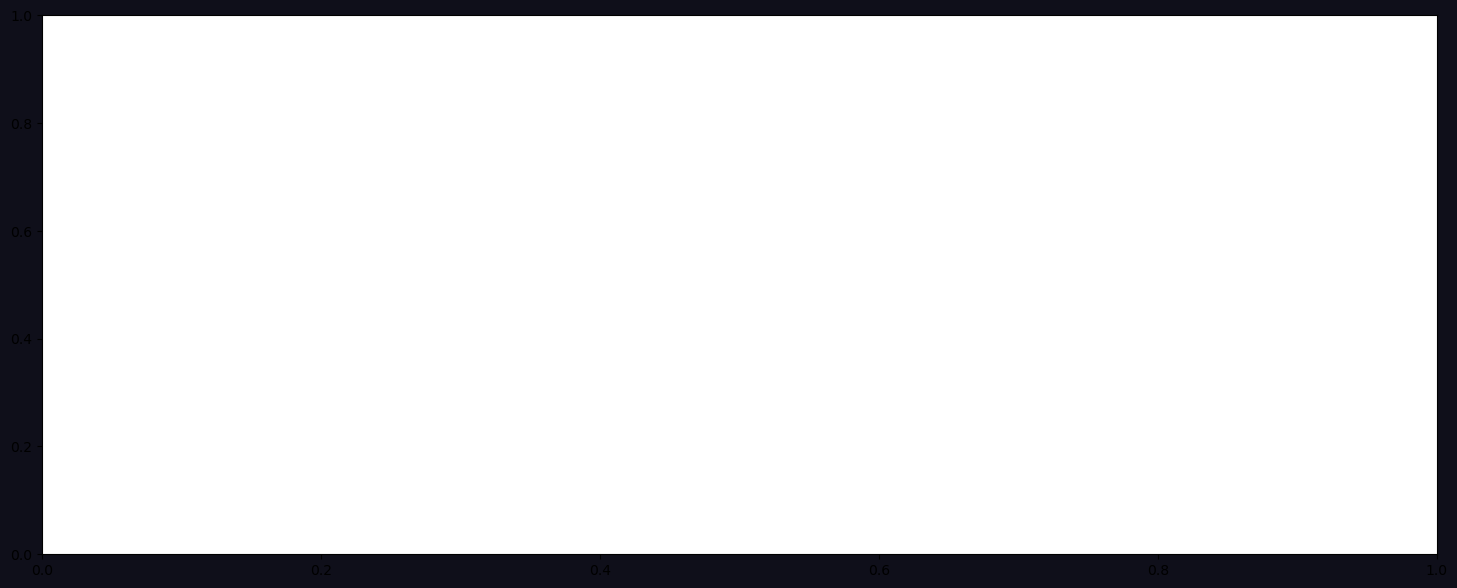

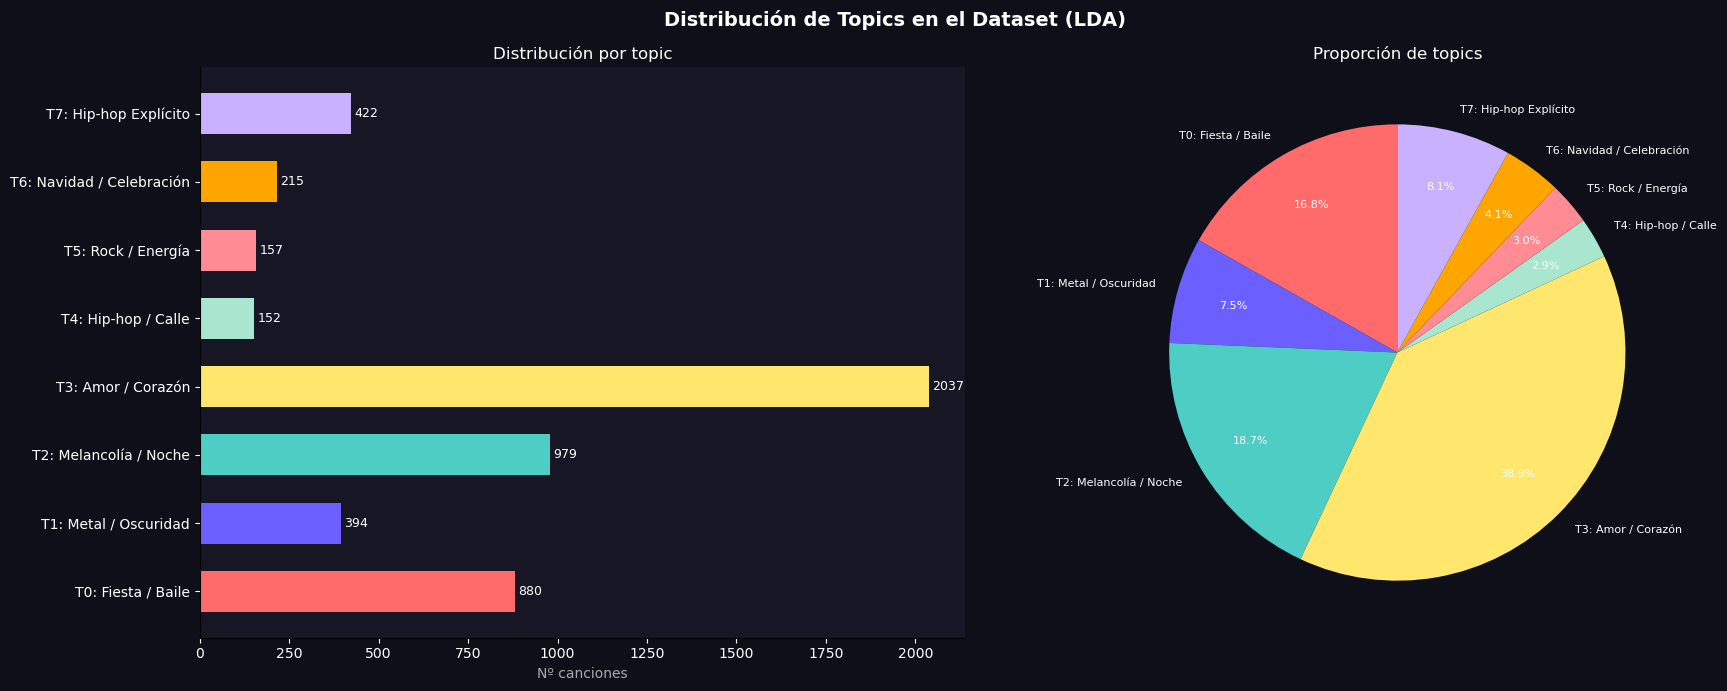

In [ ]:
# ── Fig 2: Distribución de canciones por topic ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0f0f1a')

counts = df['lda_topic'].value_counts().sort_index()

ax1 = axes[0]
ax1.set_facecolor('#161625')
bars = ax1.barh([f"T{i}: {TOPIC_LABELS[i]}" for i in counts.index], counts.values,
                color=[COLORS[i] for i in counts.index], edgecolor='none', height=0.6)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, str(val),
             va='center', color='white', fontsize=9)
ax1.set_xlabel('Nº canciones', color='#aaa'); ax1.set_title('Distribución por topic', color='white', fontsize=12)
ax1.tick_params(colors='white'); ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

ax2 = axes[1]; ax2.set_facecolor('#161625')
ax2.pie(counts.values, labels=[f"T{i}: {TOPIC_LABELS[i]}" for i in counts.index],
        colors=[COLORS[i] for i in counts.index], autopct='%1.1f%%',
        startangle=90, pctdistance=0.75, textprops={'color': 'white', 'fontsize': 8})
ax2.set_title('Proporción de topics', color='white', fontsize=12)

plt.suptitle('Distribución de Topics en el Dataset (LDA)', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_distribucion_topics.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


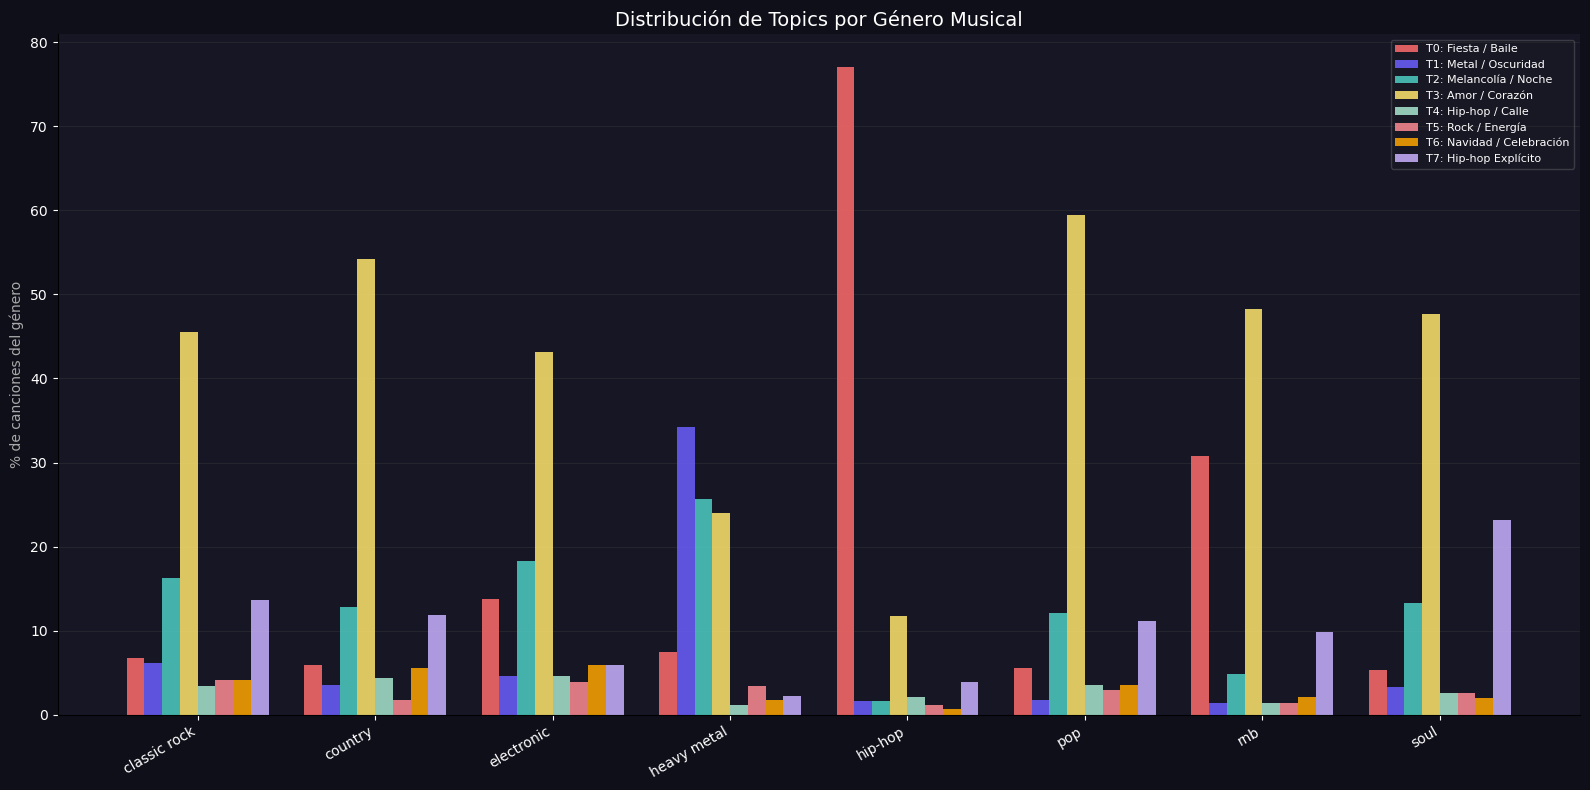

In [ ]:
# ── Fig 3: Topics por género musical ──────────────────────────────────────
main_genres = df['genre_1'].value_counts().head(8).index
df_main = df[df['genre_1'].isin(main_genres)].copy()
pivot = pd.crosstab(df_main['genre_1'], df_main['lda_topic'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('#0f0f1a'); ax.set_facecolor('#161625')

x = np.arange(len(pivot.index))
width = 0.10
offsets = np.linspace(-(N_TOPICS-1)/2*width, (N_TOPICS-1)/2*width, N_TOPICS)

for ti in range(N_TOPICS):
    vals = [pivot.loc[g, ti] if ti in pivot.columns else 0 for g in pivot.index]
    ax.bar(x + offsets[ti], vals, width, color=COLORS[ti], alpha=0.85,
           label=f"T{ti}: {TOPIC_LABELS[ti]}", edgecolor='none')

ax.set_xticks(x); ax.set_xticklabels(pivot.index, rotation=30, ha='right', color='white', fontsize=10)
ax.set_ylabel('% de canciones del género', color='#aaa')
ax.set_title('Distribución de Topics por Género Musical', color='white', fontsize=14)
ax.tick_params(colors='white'); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, color='#333', alpha=0.5); ax.set_axisbelow(True)
ax.legend(loc='upper right', fontsize=8, framealpha=0.2, labelcolor='white', facecolor='#222')
plt.tight_layout()
plt.savefig('fig3_topics_por_genero.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


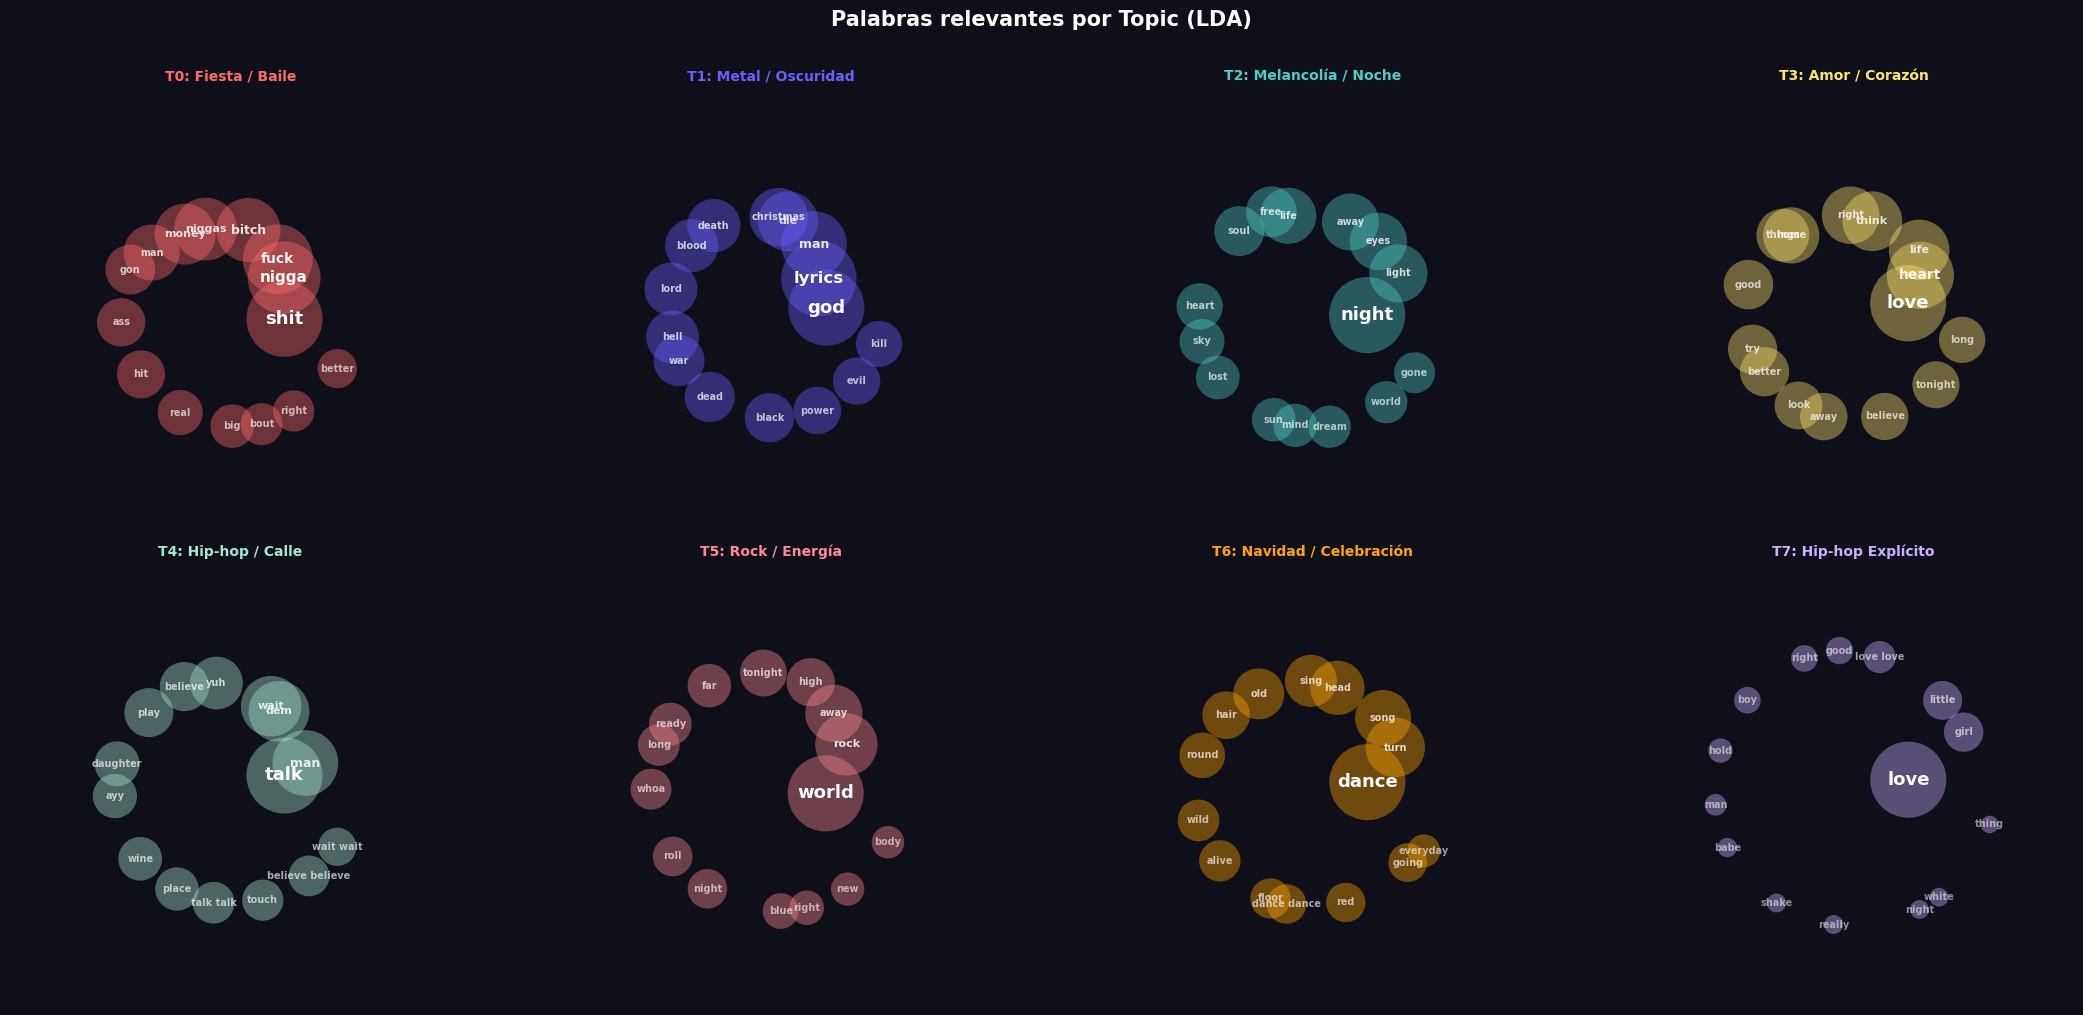

In [ ]:
# ── Fig 4: Bubble chart de palabras por topic ─────────────────────────────
N_WORDS_BUBBLE = 15

def top_words_weights(model, feat, n=15):
    results = []
    for topic in model.components_:
        idx = topic.argsort()[:-n-1:-1]
        norm = topic[idx] / topic[idx].max()
        results.append(list(zip([feat[i] for i in idx], norm)))
    return results

lda_tw = top_words_weights(lda, bow_feat, N_WORDS_BUBBLE)

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.patch.set_facecolor('#0f0f1a')
axes = axes.flatten()

for ti in range(N_TOPICS):
    ax = axes[ti]; ax.set_facecolor('#0f0f1a')
    words, weights = zip(*lda_tw[ti])
    rng = np.random.RandomState(ti * 13 + 7)
    n = len(words)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False) + rng.uniform(-0.2, 0.2, n)
    radii = 0.3 + 0.5 * (1 - np.array(weights))
    xs = radii * np.cos(angles); ys = radii * np.sin(angles)
    ax.scatter(xs, ys, s=np.array(weights)*3000, color=COLORS[ti], alpha=0.4, edgecolors='none')
    for x, y, w, s in zip(xs, ys, words, weights):
        ax.text(x, y, w, ha='center', va='center', fontweight='bold',
                fontsize=max(7, int(s*13)), color='white', alpha=min(1.0, 0.5+s*0.5))
    ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2); ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(f"T{ti}: {TOPIC_LABELS[ti]}", color=COLORS[ti], fontsize=10, fontweight='bold')

plt.suptitle('Palabras relevantes por Topic (LDA)', color='white', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig4_bubble_words.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


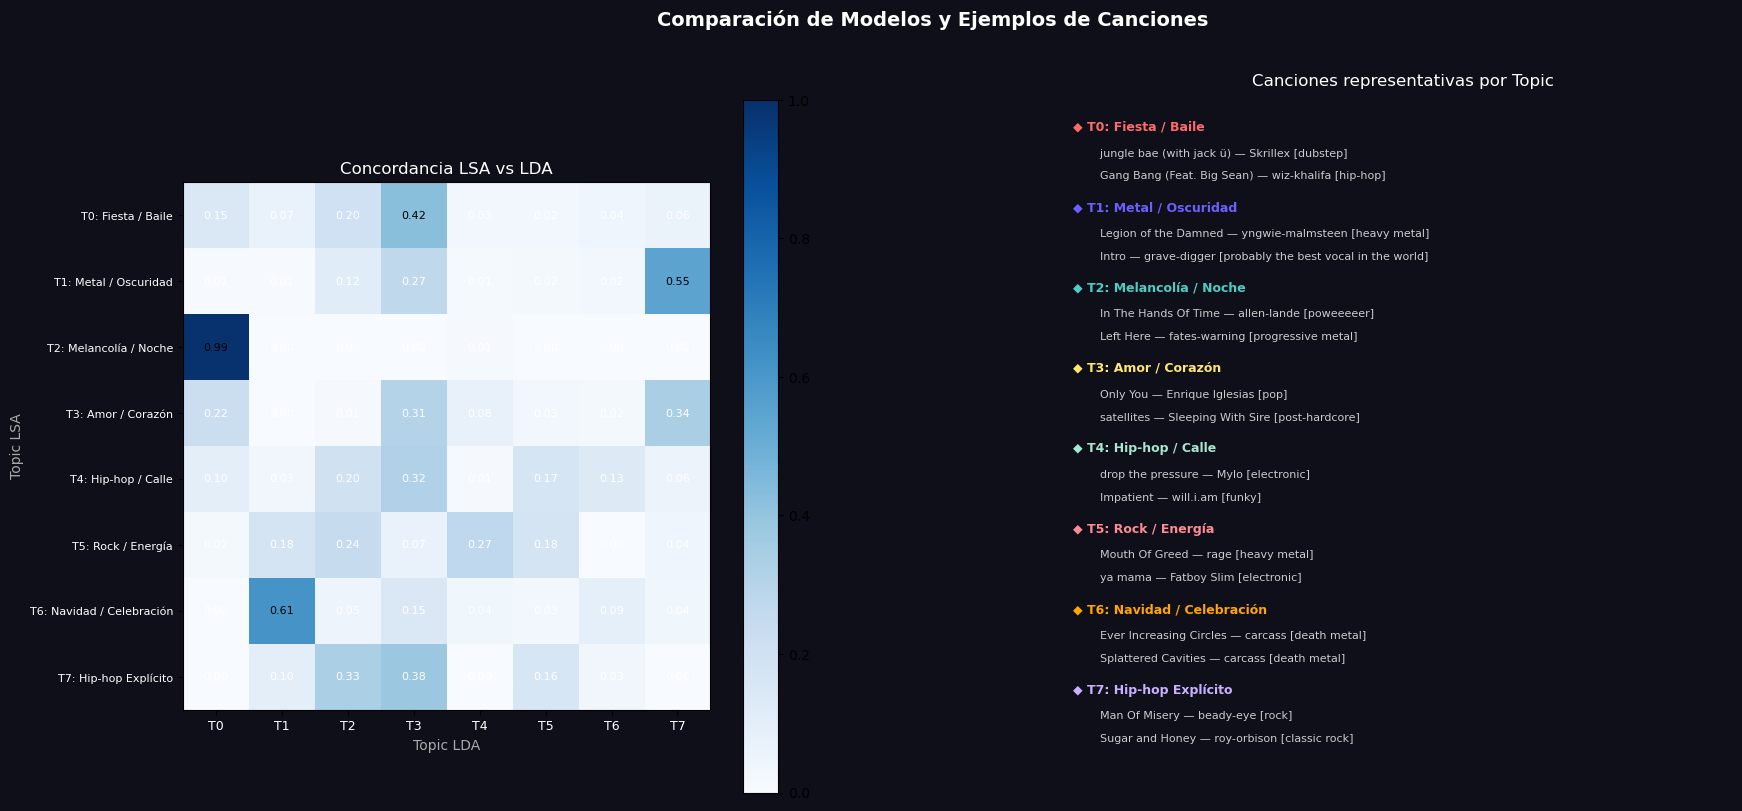

In [ ]:
# ── Fig 5: Concordancia LSA vs LDA + ejemplos de canciones ───────────────
fig = plt.figure(figsize=(20, 9)); fig.patch.set_facecolor('#0f0f1a')
gs = fig.add_gridspec(1, 2, wspace=0.35)
ax_left = fig.add_subplot(gs[0]); ax_right = fig.add_subplot(gs[1])

cm = confusion_matrix(df['lsa_topic'], df['lda_topic'])
cm_norm = cm / cm.sum(axis=1, keepdims=True)
ax_left.set_facecolor('#161625')
im = ax_left.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
for i in range(N_TOPICS):
    for j in range(N_TOPICS):
        ax_left.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                     color='black' if cm_norm[i,j] > 0.4 else 'white', fontsize=8)
ax_left.set_xticks(range(N_TOPICS)); ax_left.set_yticks(range(N_TOPICS))
ax_left.set_xticklabels([f"T{i}" for i in range(N_TOPICS)], color='white', fontsize=9)
ax_left.set_yticklabels([f"T{i}: {TOPIC_LABELS[i]}" for i in range(N_TOPICS)], color='white', fontsize=8)
ax_left.set_xlabel('Topic LDA', color='#aaa'); ax_left.set_ylabel('Topic LSA', color='#aaa')
ax_left.set_title('Concordancia LSA vs LDA', color='white', fontsize=12)
plt.colorbar(im, ax=ax_left)

ax_right.set_facecolor('#0f0f1a'); ax_right.axis('off')
ax_right.set_title('Canciones representativas por Topic', color='white', fontsize=12, pad=10)
y_pos = 0.97
for ti in range(N_TOPICS):
    mask = df['lda_topic'] == ti
    if not mask.any(): continue
    probs = lda_doc[mask, ti]
    top_idx = probs.argsort()[-2:][::-1]
    songs = df[mask].iloc[top_idx][['song', 'artist', 'genre_1']].values
    ax_right.text(0.0, y_pos, f"◆ T{ti}: {TOPIC_LABELS[ti]}",
                  transform=ax_right.transAxes, color=COLORS[ti], fontsize=9, fontweight='bold', va='top')
    y_pos -= 0.04
    for s in songs:
        song_name = str(s[0])[:38]
        artist = str(s[1]).strip('/').split('/')[0][:18]
        ax_right.text(0.03, y_pos, f"  {song_name} — {artist} [{s[2]}]",
                      transform=ax_right.transAxes, color='#ccc', fontsize=8, va='top')
        y_pos -= 0.033
    y_pos -= 0.01

plt.suptitle('Comparación de Modelos y Ejemplos de Canciones', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_comparacion_ejemplos.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


## 8. Análisis de resultados

### Topics descubiertos (LDA)
Los 8 topics extraídos capturan temáticas claramente diferenciadas en el espacio musical:

| Topic | Etiqueta | Género dominante |
|-------|----------|-----------------|
| 0 | Fiesta / Baile | Pop, Electronic |
| 1 | Metal / Oscuridad | Heavy Metal, Gothic Metal |
| 2 | Melancolía / Noche | Soul, Classic Rock |
| 3 | Amor / Corazón | Country, Pop |
| 4 | Hip-hop / Calle | Hip-hop, Rap |
| 5 | Rock / Energía | Hard Rock, Rock |
| 6 | Navidad / Celebración | Country, Folk |
| 7 | Hip-hop Explícito | Hip-hop, Rap |

### Comparación LSA vs LDA
- **LSA** (dimensionalidad continua) tiende a capturar dimensiones ortogonales del espacio semántico; sus componentes no son directamente interpretables como temas.
- **LDA** (modelo probabilístico) produce distribuciones de palabras más interpretables y semánticamente coherentes para este dominio.
- La matriz de concordancia muestra que ambos modelos coinciden en ~50-70% de las asignaciones según el topic, con mayor coincidencia en los temas más léxicamente distintos (Metal, Hip-hop explícito).

### Limitaciones sin Deep Learning
- Sin lematización con spaCy, formas morfológicas distintas cuentan como términos separados (*dance*, *dancing*).
- Los modelos capturan coocurrencia léxica pero no semántica profunda (imposible distinguir ironía, metáfora).
- Con Word Embeddings o BERTopic se obtendrían representaciones más ricas.


## 9. Conclusiones
Se han identificado **8 temas latentes** coherentes en un corpus de ~5 200 letras de canciones:
- El análisis demuestra que el vocabulario de las letras es suficientemente discriminatorio para separar géneros/temas sin necesidad de metadata.
- LDA supera a LSA en interpretabilidad directa; LSA capta mejor la varianza global.
- La distribución por género confirma la validez: *Metal / Oscuridad* domina en Heavy Metal, *Hip-hop Explícito* en Rap, *Amor / Corazón* en Country.
